# E-Commerce Analytics — Part 1: Data Cleaning, EDA & Product Analysis

**Author:** Nikhil Kumar  
**Dataset:** Online Retail — a UK-based online gift retailer. 541,909 transaction line items, Dec 2010 to Dec 2011.  
**Stack:** Python, pandas, NumPy, Matplotlib, Seaborn

---

## Objective
Turn a raw, uncleaned transactional export into an analysis-ready dataset, then use it to answer concrete
business questions about **what sells, when it sells, and where revenue is concentrated**.

## Contents
1. [Setup](#setup)
2. [Load raw data](#load)
3. [Data quality assessment](#quality) — quantify every defect before touching the data
4. [Data cleaning](#cleaning) — apply and *audit* each decision so row loss is fully traceable
5. [Feature engineering](#features)
6. [Exploratory data analysis](#eda) — sales trend, demand timing, geography
7. [Product analysis](#product) — best sellers, ABC/Pareto classification, returns
8. [Key findings](#findings)

The cleaned dataset produced here (`data_cleaned.csv`) is the input for
**Part 2 — `customer_analysis.ipynb`** (RFM segmentation, K-Means clustering, cohort retention, forecasting).

### Column dictionary

| Column | Description |
|:---|:---|
| `InvoiceNo` | Transaction ID. A leading `C` marks a **cancellation** |
| `StockCode` | Product ID |
| `Description` | Product name |
| `Quantity` | Units per line item (negative on cancellations) |
| `InvoiceDate` | Transaction timestamp |
| `UnitPrice` | Price per unit, GBP |
| `CustomerID` | Customer ID (missing for guest / unregistered checkouts) |
| `Country` | Customer country |

<a id="setup"></a>
## 1. Setup

In [1]:
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Consistent, presentation-ready plot defaults
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})
ACCENT, ACCENT2, MUTED, RED, GREEN = "#2563eb", "#f59e0b", "#94a3b8", "#ef4444", "#16a34a"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RAW_PATH = "../data.csv"
CLEAN_PATH = "../data_cleaned.csv"
VIEWS = "../views"


def gbp(v, _=None):
    """Axis formatter: 1234567 -> '1.2M', 45000 -> '45k'."""
    if abs(v) >= 1_000_000:
        return f"{v/1_000_000:,.1f}M"
    return f"{v/1_000:,.0f}k"


def shorten(s, n=32):
    return s if len(s) <= n else s[: n - 1] + "..."


def row_key(frame, *columns):
    """Row-wise key across several columns, for membership tests between frames."""
    return pd.MultiIndex.from_frame(frame.loc[:, list(columns)])


def share_bars(ax, left, right, left_label, right_label, headroom=1.18):
    """Side-by-side 'share of catalogue vs share of revenue' bars with value labels."""
    x, width = np.arange(len(left)), 0.38
    ax.bar(x - width / 2, left, width, color=MUTED, label=left_label)
    ax.bar(x + width / 2, right, width, color=ACCENT, label=right_label)
    tallest = max(max(left), max(right))
    for i, (lv, rv) in enumerate(zip(left, right)):
        ax.text(i - width / 2, lv + tallest * 0.02, f"{lv:.0f}%", ha="center", fontsize=9)
        ax.text(i + width / 2, rv + tallest * 0.02, f"{rv:.0f}%", ha="center", fontsize=9,
                fontweight="bold")
    ax.set(xticks=x, ylabel="%", ylim=(0, tallest * headroom))
    ax.legend(fontsize=9)

<a id="load"></a>
## 2. Load raw data

In [2]:
df_raw = pd.read_csv(RAW_PATH, encoding="ISO-8859-1")

print(f"Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}")
df_raw.head()

Rows: 541,909   Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [4]:
# InvoiceDate arrives as text -> parse explicitly instead of relying on inference
df_raw["InvoiceDate"] = pd.to_datetime(df_raw["InvoiceDate"], format="%m/%d/%Y %H:%M")

print("Date range:", df_raw["InvoiceDate"].min(), "to", df_raw["InvoiceDate"].max())
print(f"Span: {(df_raw['InvoiceDate'].max() - df_raw['InvoiceDate'].min()).days} days")

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Span: 373 days


In [5]:
df_raw.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


The summary statistics already expose three defects:

- `Quantity` spans **-80,995 to 80,995** — negatives are returns/cancellations, not sales
- `UnitPrice` has a **negative minimum (-11,062)** — impossible for a price; these are ledger adjustments
- `CustomerID` count (406,829) falls well short of the row count (541,909) — a large block of missing IDs

<a id="quality"></a>
## 3. Data quality assessment

Quantify every issue *before* removing anything, so each cleaning decision is evidence-based.

In [6]:
missing = df_raw.isna().sum()
quality = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": (missing / len(df_raw) * 100).round(2),
    "unique_values": df_raw.nunique(),
    "dtype": df_raw.dtypes.astype(str),
})
quality

,missing_count,missing_pct,unique_values,dtype
InvoiceNo,0,0.00,25900,str
StockCode,0,0.00,4070,str
Description,1454,0.27,4223,str
Quantity,0,0.00,722,int64
InvoiceDate,0,0.00,23260,datetime64[us]
UnitPrice,0,0.00,1630,float64
CustomerID,135080,24.93,4372,float64
Country,0,0.00,38,str


In [7]:
n_raw = len(df_raw)
is_cancel_raw = df_raw["InvoiceNo"].astype(str).str.startswith("C")

issues = pd.Series({
    "Missing CustomerID":   df_raw["CustomerID"].isna().sum(),
    "Missing Description":  df_raw["Description"].isna().sum(),
    "Exact duplicate rows": df_raw.duplicated().sum(),
    "Cancelled line items": int(is_cancel_raw.sum()),
    "Quantity <= 0":        int((df_raw["Quantity"] <= 0).sum()),
    "UnitPrice <= 0":       int((df_raw["UnitPrice"] <= 0).sum()),
}, name="rows").to_frame()
issues["% of dataset"] = (issues["rows"] / n_raw * 100).round(2)
issues

,rows,% of dataset
Missing CustomerID,135080,24.93
Missing Description,1454,0.27
Exact duplicate rows,5268,0.97
Cancelled line items,9288,1.71
Quantity <= 0,10624,1.96
UnitPrice <= 0,2517,0.46


### 3.1 Missing `CustomerID` — can it be recovered?

In [8]:
no_id = df_raw[df_raw["CustomerID"].isna()]

print(f"Rows without CustomerID : {len(no_id):,} ({len(no_id)/n_raw:.1%})")
print(f"  also missing Description: {no_id['Description'].isna().sum():,}")
print(f"  distinct invoices       : {no_id['InvoiceNo'].nunique():,}")
print(f"  value involved          : GBP {(no_id['Quantity'] * no_id['UnitPrice']).sum():,.0f}")
print()
print("Are ALL missing Descriptions inside the missing-CustomerID block?",
      bool(df_raw.loc[df_raw["Description"].isna(), "CustomerID"].isna().all()))
print()
print("Negative quantities that are NOT cancellations:")
odd_neg = df_raw[(df_raw["Quantity"] <= 0) & (~is_cancel_raw)]
print(f"  {len(odd_neg):,} rows, of which {odd_neg['CustomerID'].isna().sum():,} lack a CustomerID")
print(odd_neg["Description"].value_counts().head(6).to_string())

Rows without CustomerID : 135,080 (24.9%)
  also missing Description: 1,454
  distinct invoices       : 3,710
  value involved          : GBP 1,447,682

Are ALL missing Descriptions inside the missing-CustomerID block? True

Negative quantities that are NOT cancellations:
  1,336 rows, of which 1,336 lack a CustomerID
Description
check                    120
damages                   45
damaged                   42
?                         41
sold as set on dotcom     20
Damaged                   14


Two findings here:

1. **There is no key to impute a customer identity from** — these are unregistered/guest checkouts. Every
   downstream analysis (RFM, clustering, cohorts) is *per customer*, so these rows cannot be used. Usefully,
   all 1,454 missing `Description` values sit inside this same block, so that defect resolves along with it.
2. The negative quantities that are *not* cancellations are **inventory write-offs**, not customer activity —
   their descriptions read `check`, `damages`, `damaged`, `thrown away`, `Unsaleable, destroyed`. All of them
   sit inside the missing-`CustomerID` block too, so they are removed by the same step.

### 3.2 Non-product `StockCode`s

Genuine product codes follow the pattern *5 digits + optional letter suffix* (e.g. `85123A`). Anything else
is worth inspecting, because postage, fees and manual ledger adjustments would otherwise pollute every
product ranking and basket metric.

In [9]:
PRODUCT_CODE = re.compile(r"\d{5}[A-Za-z]{0,3}$")
codes = df_raw["StockCode"].astype(str)
odd_codes = sorted(c for c in codes.unique() if not PRODUCT_CODE.fullmatch(c))

# Judgement call per code. Codes describing a real physical item are KEPT even though
# their format is unusual; only genuine non-inventory records are dropped.
DROP_REASON = {
    "POST": "postage charge", "DOT": "DOTCOM postage", "C2": "carriage charge",
    "M": "manual ledger adjustment", "m": "manual ledger adjustment",
    "D": "discount", "S": "free samples", "B": "bad-debt adjustment",
    "BANK CHARGES": "bank fee", "AMAZONFEE": "marketplace fee", "CRUK": "charity commission",
    "gift_0001_10": "gift voucher", "gift_0001_20": "gift voucher", "gift_0001_30": "gift voucher",
    "gift_0001_40": "gift voucher", "gift_0001_50": "gift voucher",
}

# Summarise the odd codes in one pass instead of re-scanning the frame per code
odd_rows = df_raw.assign(StockCode=codes).query("StockCode in @odd_codes").groupby("StockCode")

audit_codes = pd.DataFrame({"StockCode": odd_codes})
audit_codes["description"] = audit_codes["StockCode"].map(odd_rows["Description"].first()).fillna("-")
audit_codes["rows"] = audit_codes["StockCode"].map(odd_rows.size())
audit_codes["decision"] = np.where(audit_codes["StockCode"].isin(DROP_REASON), "DROP", "keep")
audit_codes["reason"] = audit_codes["StockCode"].map(DROP_REASON).fillna("real product, unusual code")

NON_PRODUCT = list(DROP_REASON)
print(f"{len(odd_codes)} non-standard codes found -> dropping {len(NON_PRODUCT)}, "
      f"keeping {len(odd_codes) - len(NON_PRODUCT)}")
print(f"Rows affected by the drop: {codes.isin(NON_PRODUCT).sum():,}")
audit_codes

33 non-standard codes found -> dropping 16, keeping 17
Rows affected by the drop: 2,946


,StockCode,description,rows,decision,reason
0,AMAZONFEE,AMAZON FEE,34,DROP,marketplace fee
1,B,Adjust bad debt,3,DROP,bad-debt adjustment
2,BANK CHARGES,Bank Charges,37,DROP,bank fee
3,C2,CARRIAGE,144,DROP,carriage charge
4,CRUK,CRUK Commission,16,DROP,charity commission
5,D,Discount,77,DROP,discount
6,DCGS0003,BOXED GLASS ASHTRAY,5,keep,"real product, unusual code"
7,DCGS0004,HAYNES CAMPER SHOULDER BAG,1,keep,"real product, unusual code"
8,DCGS0055,-,1,keep,"real product, unusual code"
9,DCGS0057,-,1,keep,"real product, unusual code"


The `DCGS*` codes (dog collars, party bags, a glass ashtray) and `PADS` describe **real merchandise** and are
kept. Only the 16 codes representing postage, fees, discounts, samples and vouchers are dropped — a blanket
"non-numeric code" filter would have wrongly deleted genuine products.

<a id="cleaning"></a>
## 4. Data cleaning

Applied in sequence, with the row count logged after each step so the exact cost of every decision is visible.

| # | Step | Reason |
|:--|:---|:---|
| 1 | Drop exact duplicate rows | Repeated system writes; would double-count revenue |
| 2 | Drop rows with missing `CustomerID` | Guest checkouts and stock write-offs; not attributable to a customer |
| 3 | Drop non-product `StockCode`s | Postage, fees, vouchers and adjustments are not products |
| 4 | Drop `UnitPrice <= 0` | Free/adjustment records; invalid for revenue analysis |
| 5 | Split out cancellations | Kept aside for return analysis, excluded from sales |
| 6 | Remove reversed bulk orders | Data-entry errors cancelled minutes later (see 4.1) |

In [10]:
audit = []

def log(step, frame):
    audit.append({"step": step, "rows": len(frame)})
    return frame

df = df_raw.copy()
log("0. Raw data", df)

df = log("1. Drop duplicates",         df.drop_duplicates())
df = log("2. Drop missing CustomerID", df.dropna(subset=["CustomerID"]))
df = log("3. Drop non-product codes",  df[~df["StockCode"].astype(str).isin(NON_PRODUCT)])
df = log("4. Drop UnitPrice <= 0",     df[df["UnitPrice"] > 0])

df["CustomerID"] = df["CustomerID"].astype("int64")

# Cancellations are real business events, just not sales -> hold them aside for return analysis
is_cancel = df["InvoiceNo"].astype(str).str.startswith("C")
df_cancelled = df[is_cancel].copy()
df = log("5. Split out cancellations", df[~is_cancel])

pd.DataFrame(audit)

,step,rows
0,0. Raw data,541909
1,1. Drop duplicates,536641
2,2. Drop missing CustomerID,401604
3,3. Drop non-product codes,399693
4,4. Drop UnitPrice <= 0,399659
5,5. Split out cancellations,391153


### 4.1 Outlier check — reversed bulk orders

The largest `Quantity` values are extreme (80,995 units on a single line). Before treating them as outliers to
be clipped, it is worth asking *what they actually are*: if a matching cancellation exists for the same
customer, product and quantity, the "sale" was reversed and never represented real revenue.

In [11]:
BULK = 1_000  # only large lines can materially distort aggregates

cancel_keys = (df_cancelled.assign(AbsQty=df_cancelled["Quantity"].abs())
                           [["CustomerID", "StockCode", "AbsQty"]]
                           .drop_duplicates())

reversed_lines = (df[df["Quantity"] >= BULK]
                  .merge(cancel_keys,
                         left_on=["CustomerID", "StockCode", "Quantity"],
                         right_on=["CustomerID", "StockCode", "AbsQty"],
                         how="inner"))
reversed_lines["Revenue"] = reversed_lines["Quantity"] * reversed_lines["UnitPrice"]

print(f"Bulk sale lines with an exactly matching cancellation: {len(reversed_lines)}")
print(f"Phantom revenue they contribute: GBP {reversed_lines['Revenue'].sum():,.0f}")
reversed_lines[["InvoiceNo", "StockCode", "Description", "Quantity",
                "UnitPrice", "Revenue", "CustomerID", "InvoiceDate"]].sort_values("Revenue", ascending=False)

Bulk sale lines with an exactly matching cancellation: 13
Phantom revenue they contribute: GBP 280,404


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,InvoiceDate
12,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446,2011-12-09 09:15:00
3,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346,2011-01-18 10:01:00
2,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749,2011-01-11 12:55:00
6,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749,2011-04-18 13:20:00
0,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,4921.50,15749,2011-01-11 12:55:00
4,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.40,4632.00,15749,2011-04-18 13:20:00
1,540815,21175,GIN + TONIC DIET METAL SIGN,2000,1.85,3700.00,15749,2011-01-11 12:55:00
5,550461,21175,GIN + TONIC DIET METAL SIGN,2000,1.69,3380.00,15749,2011-04-18 13:20:00
9,570094,20971,PINK BLUE FELT CRAFT TRINKET BOX,1296,1.06,1373.76,16029,2011-10-07 11:56:00
10,570097,20971,PINK BLUE FELT CRAFT TRINKET BOX,1296,1.06,1373.76,16029,2011-10-07 12:05:00


In [12]:
# Inspect the single largest case end to end
case = pd.concat([
    df[df["InvoiceNo"] == "581483"],
    df_cancelled[df_cancelled["InvoiceNo"] == "C581484"],
])[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID", "InvoiceDate"]]
case

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,InvoiceDate
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,2011-12-09 09:15:00
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,16446,2011-12-09 09:27:00


Customer 16446 "bought" 80,995 paper-craft units worth **£168,470 at 09:15** and cancelled the entire order
**12 minutes later at 09:27**. The second-largest case (£77,184) follows the same pattern, 16 minutes apart.

These are **data-entry errors, not sales**. Left in, they would have ranked as the #1 and #2 products by
revenue and distorted every product-level metric. Removing the matched sale *and* its cancellation from both
frames is more correct than clipping the quantity, because it eliminates a phantom transaction rather than
disguising it.

In [13]:
# Remove the phantom sale lines, and the cancellations that reversed them, from both frames
sold_key = row_key(reversed_lines, "InvoiceNo", "StockCode")
df = log("6. Remove reversed bulk orders",
         df[~row_key(df, "InvoiceNo", "StockCode").isin(sold_key)])

cancelled_key = row_key(reversed_lines, "CustomerID", "StockCode", "Quantity")
cancels = df_cancelled.assign(AbsQty=df_cancelled["Quantity"].abs())
df_cancelled = df_cancelled[~row_key(cancels, "CustomerID", "StockCode", "AbsQty").isin(cancelled_key)]

df = df.reset_index(drop=True)

audit_df = pd.DataFrame(audit)
audit_df["rows_removed"] = -audit_df["rows"].diff().fillna(0).astype(int)
audit_df["% of raw retained"] = (audit_df["rows"] / n_raw * 100).round(1)
audit_df

,step,rows,rows_removed,% of raw retained
0,0. Raw data,541909,0,100.0
1,1. Drop duplicates,536641,5268,99.0
2,2. Drop missing CustomerID,401604,135037,74.1
3,3. Drop non-product codes,399693,1911,73.8
4,4. Drop UnitPrice <= 0,399659,34,73.8
5,5. Split out cancellations,391153,8506,72.2
6,6. Remove reversed bulk orders,391140,13,72.2


In [14]:
# The cleaned frame must satisfy every assumption downstream code relies on
assert df.isna().sum().sum() == 0,  "cleaned data still contains nulls"
assert (df["Quantity"] > 0).all(),  "non-positive quantity survived cleaning"
assert (df["UnitPrice"] > 0).all(), "non-positive price survived cleaning"
assert not df.duplicated().any(),   "duplicate rows survived cleaning"
assert not df["InvoiceNo"].astype(str).str.startswith("C").any(), "cancellation survived cleaning"

print("All data-quality assertions passed.")
print(f"Retained {len(df):,} of {n_raw:,} rows ({len(df)/n_raw:.1%}).")
print(f"Held aside {len(df_cancelled):,} cancellation line items for return analysis.")

All data-quality assertions passed.
Retained 391,140 of 541,909 rows (72.2%).
Held aside 8,498 cancellation line items for return analysis.


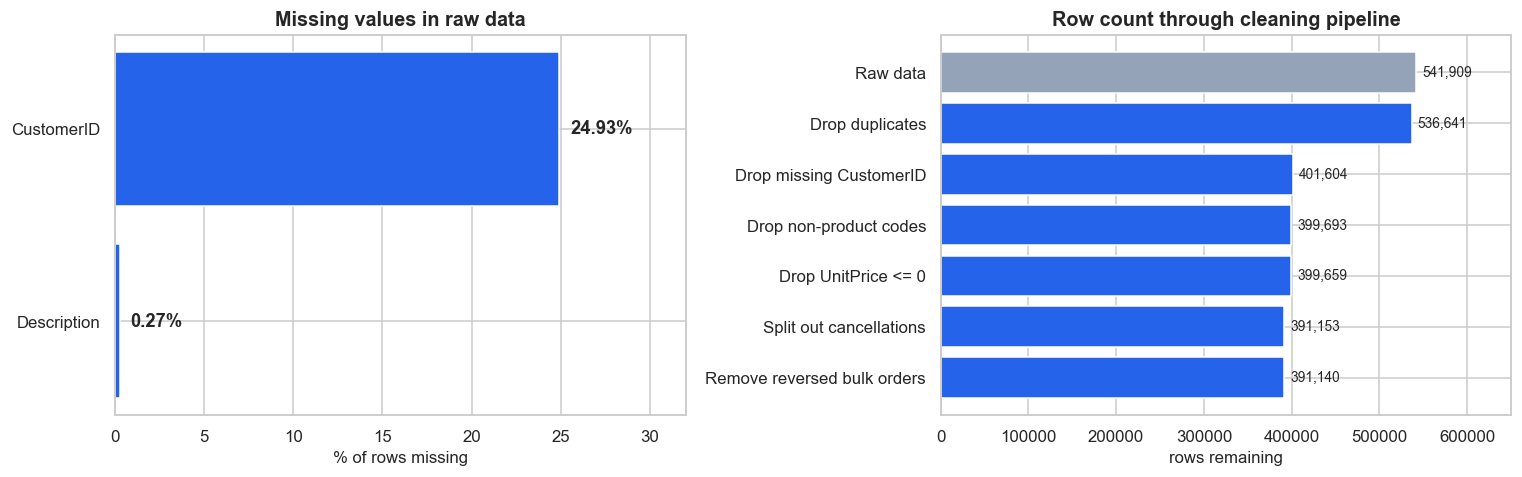

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

miss = quality.loc[quality["missing_pct"] > 0, "missing_pct"].sort_values()
ax[0].barh(miss.index, miss.values, color=ACCENT)
for i, v in enumerate(miss.values):
    ax[0].text(v + 0.6, i, f"{v:.2f}%", va="center", fontweight="bold")
ax[0].set(xlim=(0, 32), xlabel="% of rows missing", title="Missing values in raw data")

steps = audit_df["step"].str.replace(r"^\d\. ", "", regex=True)
ax[1].barh(steps, audit_df["rows"], color=[MUTED] + [ACCENT] * (len(audit_df) - 1))
for i, v in enumerate(audit_df["rows"]):
    ax[1].text(v + 7000, i, f"{v:,}", va="center", fontsize=9)
ax[1].invert_yaxis()
ax[1].set(xlim=(0, n_raw * 1.2), xlabel="rows remaining", title="Row count through cleaning pipeline")

plt.tight_layout()
plt.savefig(f"{VIEWS}/data_quality.png")
plt.show()

<a id="features"></a>
## 5. Feature engineering

Only features that later analysis actually consumes:

- **`Revenue`** = `Quantity` x `UnitPrice` — the money metric behind every aggregation
- **Calendar parts** (`Year`, `Month`, `YearMonth`, `DayOfWeek`, `Hour`, `InvoiceDay`) — for trend and demand-timing analysis

In [16]:
for frame in (df, df_cancelled):
    frame["Revenue"] = frame["Quantity"] * frame["UnitPrice"]

df["InvoiceDay"] = df["InvoiceDate"].dt.normalize()
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceDay,Year,Month,YearMonth,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12-01,2010,12,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,2010,12,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12-01,2010,12,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,2010,12,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,2010,12,2010-12,Wednesday,8


In [17]:
df.to_csv(CLEAN_PATH, index=False)
print(f"Cleaned dataset saved -> {CLEAN_PATH}  ({df.shape[0]:,} rows x {df.shape[1]} columns)")

Cleaned dataset saved -> ../data_cleaned.csv  (391,140 rows x 15 columns)


<a id="eda"></a>
## 6. Exploratory data analysis

### 6.1 Business overview

In [18]:
kpi = pd.Series({
    "Total revenue (GBP)":        df["Revenue"].sum(),
    "Orders":                     df["InvoiceNo"].nunique(),
    "Customers":                  df["CustomerID"].nunique(),
    "Products":                   df["StockCode"].nunique(),
    "Countries":                  df["Country"].nunique(),
    "Average order value (GBP)":  df["Revenue"].sum() / df["InvoiceNo"].nunique(),
    "Revenue per customer (GBP)": df["Revenue"].sum() / df["CustomerID"].nunique(),
    "Units per order":            df["Quantity"].sum() / df["InvoiceNo"].nunique(),
    "Orders per customer":        df["InvoiceNo"].nunique() / df["CustomerID"].nunique(),
})
kpi.round(2).to_frame("value")

,value
Total revenue (GBP),8456823.61
Orders,18399.00
Customers,4333.00
Products,3659.00
Countries,37.00
Average order value (GBP),459.63
Revenue per customer (GBP),1951.72
Units per order,269.90
Orders per customer,4.25


In [19]:
n_cancel_inv = df_cancelled["InvoiceNo"].nunique()
cancel_rate = n_cancel_inv / (df["InvoiceNo"].nunique() + n_cancel_inv)
return_value = abs(df_cancelled["Revenue"].sum())

print(f"Cancelled orders       : {n_cancel_inv:,} ({cancel_rate:.1%} of all orders placed)")
print(f"Value returned         : GBP {return_value:,.0f} ({return_value/df['Revenue'].sum():.1%} of gross sales)")
print(f"Customers who returned : {df_cancelled['CustomerID'].nunique():,} "
      f"({df_cancelled['CustomerID'].nunique()/df['CustomerID'].nunique():.1%} of the customer base)")

Cancelled orders       : 3,379 (15.5% of all orders placed)
Value returned         : GBP 208,646 (2.5% of gross sales)
Customers who returned : 1,531 (35.3% of the customer base)


### 6.2 Sales trend over time

In [20]:
monthly = df.groupby("YearMonth").agg(
    revenue=("Revenue", "sum"),
    orders=("InvoiceNo", "nunique"),
    customers=("CustomerID", "nunique"),
).reset_index()
monthly["avg_order_value"] = (monthly["revenue"] / monthly["orders"]).round(2)

# Data stops mid-month -> flag it so the final dip is not misread as a decline
last_day = df["InvoiceDate"].max()
partial = last_day.to_period("M").strftime("%Y-%m")
print(f"Data ends {last_day:%d %b %Y}, so {partial} is a PARTIAL month and not comparable.")
monthly.round(2)

Data ends 09 Dec 2011, so 2011-12 is a PARTIAL month and not comparable.


,YearMonth,revenue,orders,customers,avg_order_value
0,2010-12,565199.56,1394,884,405.45
1,2011-01,470338.41,981,738,479.45
2,2011-02,442293.59,992,757,445.86
3,2011-03,583143.85,1312,973,444.47
4,2011-04,439889.48,1139,853,386.21
5,2011-05,659242.49,1544,1054,426.97
6,2011-06,652431.67,1390,990,469.38
7,2011-07,591603.79,1321,946,447.85
8,2011-08,635514.38,1267,933,501.59
9,2011-09,938752.63,1739,1259,539.82


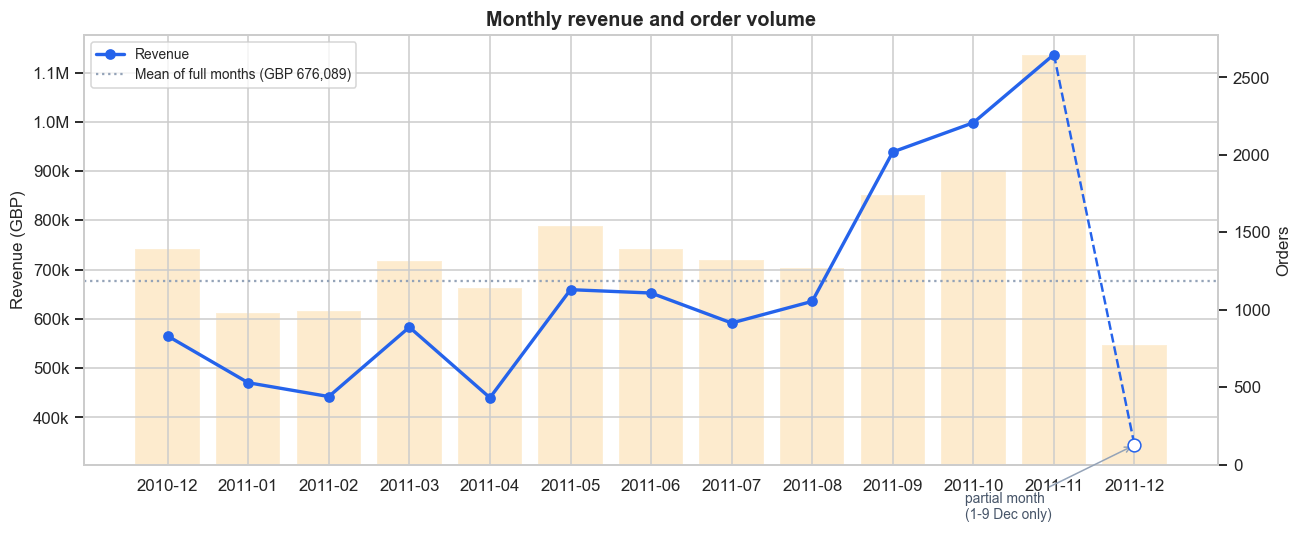

Peak   : 2011-11  GBP 1,136,534  (2,642 orders)
Trough : 2011-04  GBP 439,889  (1,139 orders)
Peak is 2.6x the trough, on 2.3x the orders (AOV 386 -> 430).


In [21]:
full = monthly[monthly["YearMonth"] != partial]

fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()
ax2.bar(monthly["YearMonth"], monthly["orders"], alpha=0.20, color=ACCENT2, label="Orders (right axis)")
ax2.grid(False)
ax2.set_ylabel("Orders")

ax.plot(full["YearMonth"], full["revenue"], marker="o", color=ACCENT, lw=2.2, label="Revenue", zorder=3)
ax.plot(monthly["YearMonth"].iloc[-2:], monthly["revenue"].iloc[-2:], ls="--", color=ACCENT, lw=1.6, zorder=3)
ax.scatter([partial], monthly["revenue"].iloc[-1:], facecolor="white", edgecolor=ACCENT, s=70, zorder=4)
ax.axhline(full["revenue"].mean(), color=MUTED, ls=":",
           label=f"Mean of full months (GBP {full['revenue'].mean():,.0f})")
ax.annotate("partial month\n(1-9 Dec only)", xy=(len(monthly) - 1, monthly["revenue"].iloc[-1]),
            xytext=(len(monthly) - 3.1, monthly["revenue"].iloc[-1] - 150_000), fontsize=9, color="#475569",
            arrowprops=dict(arrowstyle="->", color=MUTED))

ax.set(title="Monthly revenue and order volume", xlabel="", ylabel="Revenue (GBP)", zorder=3)
ax.patch.set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(gbp))
ax.legend(loc="upper left", fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{VIEWS}/sales_trend.png")
plt.show()

peak, trough = full.loc[full["revenue"].idxmax()], full.loc[full["revenue"].idxmin()]
print(f"Peak   : {peak['YearMonth']}  GBP {peak['revenue']:,.0f}  ({peak['orders']:,} orders)")
print(f"Trough : {trough['YearMonth']}  GBP {trough['revenue']:,.0f}  ({trough['orders']:,} orders)")
print(f"Peak is {peak['revenue']/trough['revenue']:.1f}x the trough, "
      f"on {peak['orders']/trough['orders']:.1f}x the orders "
      f"(AOV {trough['avg_order_value']:,.0f} -> {peak['avg_order_value']:,.0f}).")

Revenue climbs steadily and then accelerates sharply from **September to November 2011**, peaking at
**£1.14M in November** — about **2.6x the April trough (£440k)**. Decomposing that multiplier is what makes it
actionable: order volume rises **2.3x** while average order value moves only **£386 -> £430 (+11%)**. The Q4
surge is therefore driven by **many more customers ordering, not bigger baskets**. For a gift retailer this is
the Christmas run-up, and it means capacity planning (stock, packing, support) has to scale with *order count*
from September onward — pricing changes would not move this needle.

### 6.3 When do customers buy?

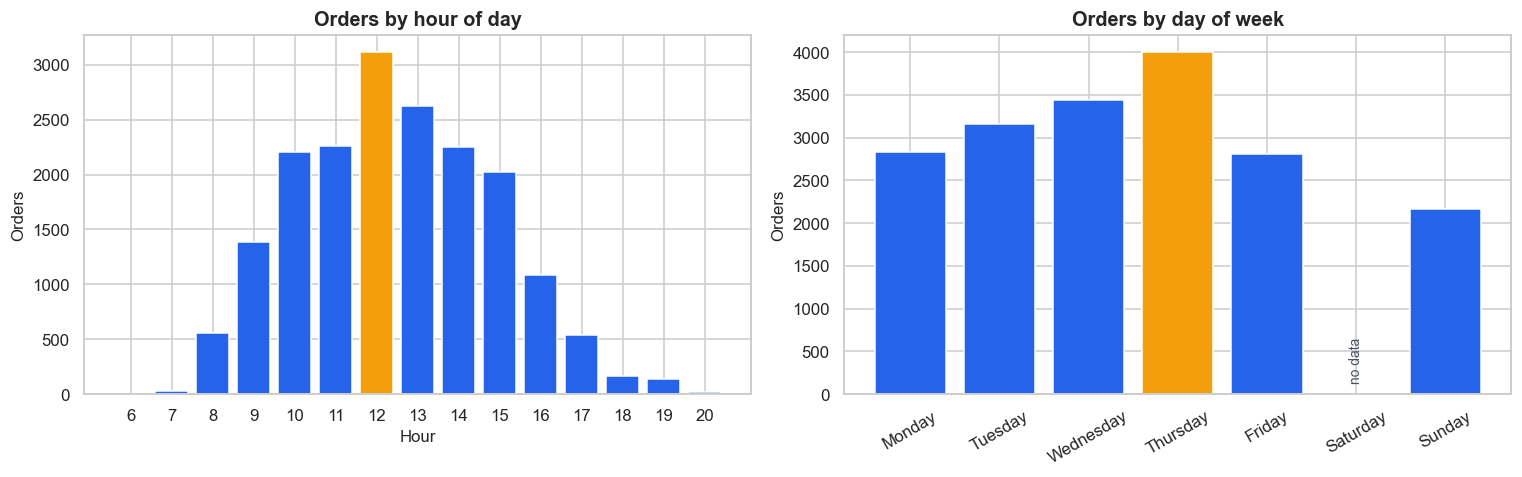

Days with zero transactions: ['Saturday']
Share of orders in the 10:00-15:00 window: 79%
Busiest hour: 12:00   Busiest day: Thursday


In [22]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

hourly = df.groupby("Hour").agg(orders=("InvoiceNo", "nunique"), revenue=("Revenue", "sum"))
weekly = (df.groupby("DayOfWeek").agg(orders=("InvoiceNo", "nunique"), revenue=("Revenue", "sum"))
            .reindex(weekday_order))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

ax[0].bar(hourly.index, hourly["orders"], color=ACCENT)
ax[0].bar([hourly["orders"].idxmax()], [hourly["orders"].max()], color=ACCENT2)
ax[0].set(title="Orders by hour of day", xlabel="Hour", ylabel="Orders", xticks=range(6, 21))

wk = weekly.fillna(0)
ax[1].bar(wk.index, wk["orders"], color=[MUTED if v == 0 else ACCENT for v in wk["orders"]])
ax[1].bar([wk["orders"].idxmax()], [wk["orders"].max()], color=ACCENT2)
ax[1].text(5, wk["orders"].max() * 0.04, "no data", ha="center", fontsize=9, color="#475569", rotation=90)
ax[1].set(title="Orders by day of week", xlabel="", ylabel="Orders")
ax[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{VIEWS}/transaction_patterns.png")
plt.show()

print("Days with zero transactions:", list(weekly.index[weekly["orders"].isna()]))
print(f"Share of orders in the 10:00-15:00 window: {hourly.loc[10:15, 'orders'].sum()/hourly['orders'].sum():.0%}")
print(f"Busiest hour: {hourly['orders'].idxmax()}:00   Busiest day: {wk['orders'].idxmax()}")

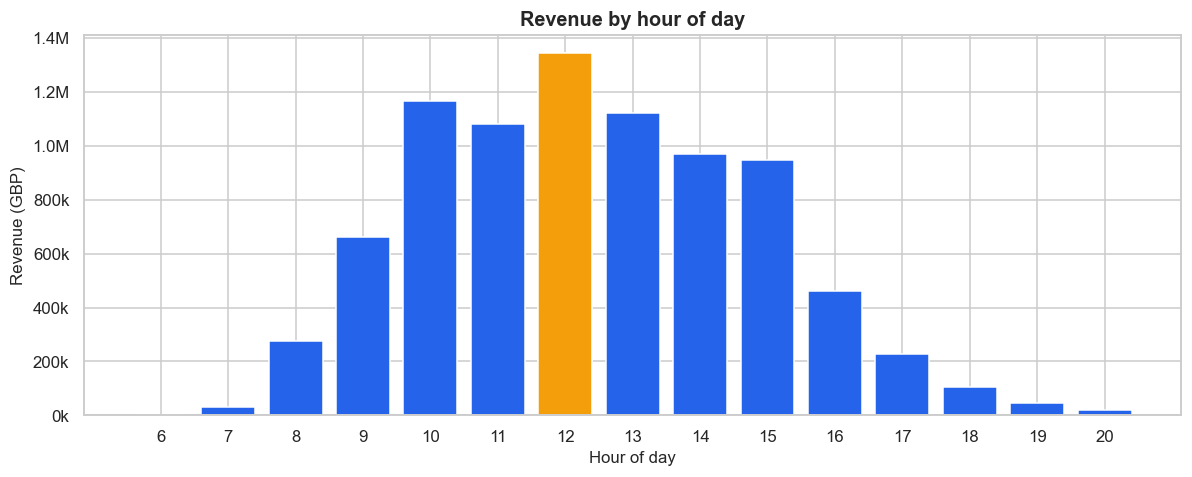

In [23]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(hourly.index, hourly["revenue"], color=ACCENT)
ax.bar([hourly["revenue"].idxmax()], [hourly["revenue"].max()], color=ACCENT2)
ax.set(title="Revenue by hour of day", xlabel="Hour of day", ylabel="Revenue (GBP)", xticks=range(6, 21))
ax.yaxis.set_major_formatter(plt.FuncFormatter(gbp))
plt.tight_layout()
plt.savefig(f"{VIEWS}/hourly_sales.png")
plt.show()

Demand sits in a narrow window: **79% of orders land between 10:00 and 15:00**, peaking at **midday**, and
there are **zero Saturday transactions in the entire year**. That is a business-process fact worth establishing
before anyone proposes a "weekend campaign". The overall shape — working-hours, midweek ordering with a
£460 average order value — points to a **wholesale/B2B-leaning customer mix** rather than evening consumer retail.

### 6.4 Geographic concentration

In [24]:
country = (df.groupby("Country")
             .agg(revenue=("Revenue", "sum"), customers=("CustomerID", "nunique"),
                  orders=("InvoiceNo", "nunique"))
             .sort_values("revenue", ascending=False))
country["revenue_share_%"] = (country["revenue"] / country["revenue"].sum() * 100).round(2)
country["avg_order_value"] = (country["revenue"] / country["orders"]).round(2)
country.head(10).round(2)

,revenue,customers,orders,revenue_share_%,avg_order_value
Country,,,,,
United Kingdom,6962451.29,3915,16576,82.33,420.03
Netherlands,283889.34,9,93,3.36,3052.57
EIRE,257013.12,3,256,3.04,1003.96
Germany,205381.15,94,443,2.43,463.61
France,183801.94,87,379,2.17,484.97
Australia,138103.81,9,56,1.63,2466.14
Spain,55706.56,30,88,0.66,633.03
Switzerland,52441.95,21,47,0.62,1115.79
Japan,37416.37,8,19,0.44,1969.28


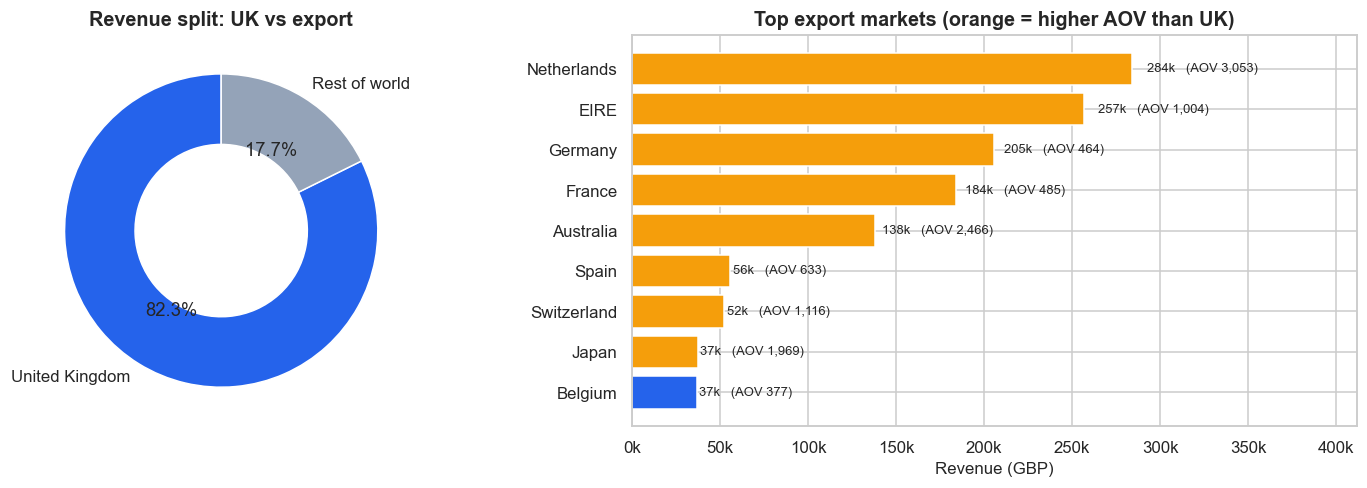

UK share of revenue: 82.3%   UK average order value: GBP 420
Export markets with AOV above the UK: Netherlands, EIRE, Germany, France, Australia, Spain, Switzerland, Japan


In [25]:
uk_rev = country.loc["United Kingdom", "revenue"]
top_c = country.drop(index="United Kingdom").head(9).iloc[::-1]
uk_aov = country.loc["United Kingdom", "avg_order_value"]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

ax[0].pie([uk_rev, country["revenue"].sum() - uk_rev], labels=["United Kingdom", "Rest of world"],
          autopct="%1.1f%%", colors=[ACCENT, MUTED], startangle=90,
          wedgeprops=dict(width=0.45, edgecolor="white"))
ax[0].set_title("Revenue split: UK vs export")

bars = ax[1].barh(top_c.index, top_c["revenue"],
                  color=[ACCENT2 if v > uk_aov else ACCENT for v in top_c["avg_order_value"]])
for i, (v, a) in enumerate(zip(top_c["revenue"], top_c["avg_order_value"])):
    ax[1].text(v * 1.03, i, f"{gbp(v)}   (AOV {a:,.0f})", va="center", fontsize=8.5)
ax[1].set(title="Top export markets (orange = higher AOV than UK)", xlabel="Revenue (GBP)",
          xlim=(0, top_c["revenue"].max() * 1.45))
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(gbp))

plt.tight_layout()
plt.savefig(f"{VIEWS}/country_revenue.png")
plt.show()

print(f"UK share of revenue: {uk_rev/country['revenue'].sum():.1%}   UK average order value: GBP {uk_aov:,.0f}")
print("Export markets with AOV above the UK:",
      ", ".join(country.drop(index="United Kingdom").query("avg_order_value > @uk_aov").head(8).index))

The business is overwhelmingly domestic — the **UK alone drives 82% of revenue**. Among export markets the
**Netherlands, Ireland (EIRE) and Germany** lead by total revenue, but the more actionable detail is average
order value: the Netherlands averages **~£3,050 per order versus ~£420 in the UK**, from just 9 customers.
A handful of large wholesale accounts sit behind those numbers, which makes named-account management a far
more efficient growth lever abroad than broad-reach marketing.

<a id="product"></a>
## 7. Product analysis

### 7.1 Best sellers

One catch: the same `StockCode` appears with slightly different `Description` spellings, so grouping on both
columns would split a single product across several rows. Products are therefore aggregated by `StockCode`,
with the most frequently used description taken as the canonical name.

In [26]:
print(f"Unique StockCodes            : {df['StockCode'].nunique():,}")
print(f"Unique StockCode+Description : {df.groupby(['StockCode', 'Description']).ngroups:,}  <- inflated")

canonical_name = (df.groupby(["StockCode", "Description"]).size().rename("n").reset_index()
                    .sort_values("n", ascending=False)
                    .drop_duplicates("StockCode")
                    .set_index("StockCode")["Description"])

product = df.groupby("StockCode").agg(
    revenue=("Revenue", "sum"),
    units=("Quantity", "sum"),
    orders=("InvoiceNo", "nunique"),
    customers=("CustomerID", "nunique"),
)
product.insert(0, "Description", canonical_name)
product["avg_price"] = (product["revenue"] / product["units"]).round(2)

print(f"Products after aggregation   : {len(product):,}")
product.nlargest(10, "revenue").round(2)

Unique StockCodes            : 3,659
Unique StockCode+Description : 3,891  <- inflated
Products after aggregation   : 3,659


,Description,revenue,units,orders,customers,avg_price
StockCode,,,,,,
22423,REGENCY CAKESTAND 3 TIER,142264.75,12374,1703,881,11.50
85123A,WHITE HANGING HEART T-LIGHT HOLDER,90993.95,32903,1976,855,2.77
85099B,JUMBO BAG RED RETROSPOT,85040.54,46078,1600,635,1.85
47566,PARTY BUNTING,68785.23,15279,1379,708,4.50
84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375,678,1.60
23084,RABBIT NIGHT LIGHT,51251.24,27153,801,450,1.89
22502,PICNIC BASKET WICKER SMALL,47348.35,1485,234,175,31.88
79321,CHILLI LIGHTS,46265.11,9646,519,205,4.80
22086,PAPER CHAIN KIT 50'S CHRISTMAS,42584.13,15591,980,613,2.73


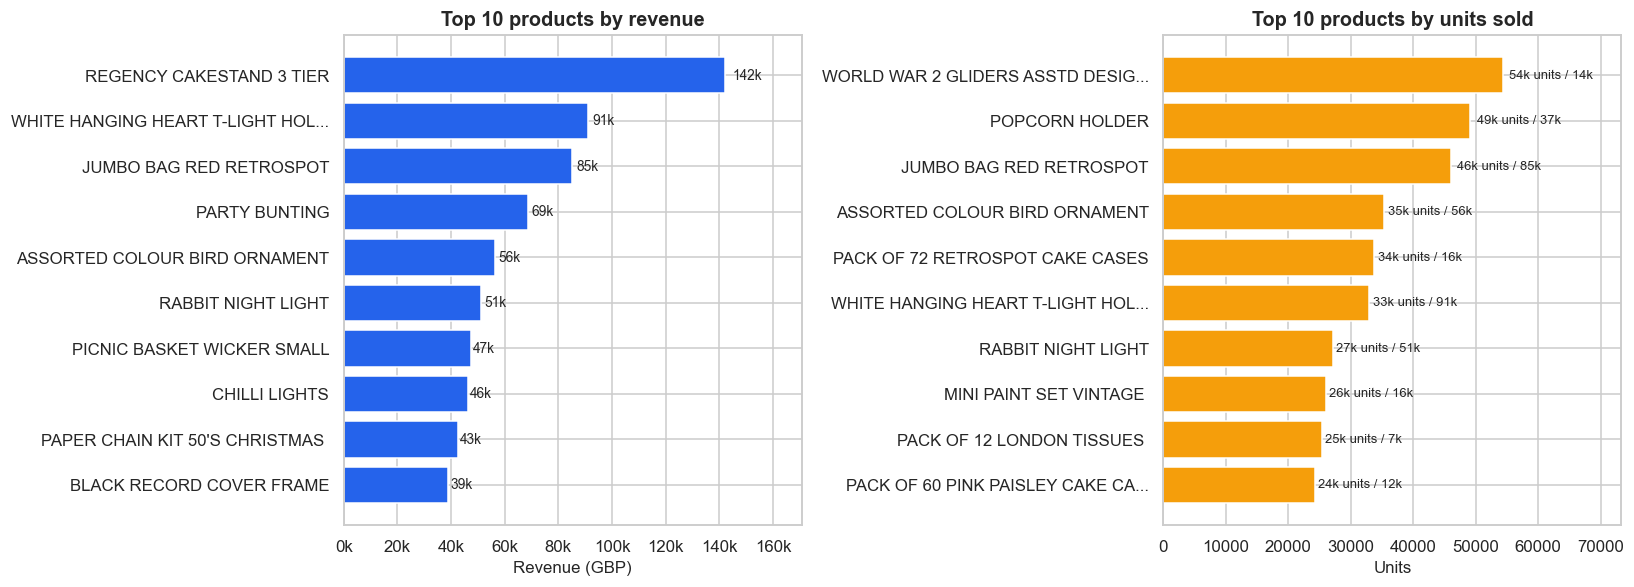

Products appearing in BOTH top-10 lists: 4 of 10


In [27]:
top_rev = product.nlargest(10, "revenue").iloc[::-1]
top_qty = product.nlargest(10, "units").iloc[::-1]

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))

ax[0].barh([shorten(d) for d in top_rev["Description"]], top_rev["revenue"], color=ACCENT)
for i, v in enumerate(top_rev["revenue"]):
    ax[0].text(v * 1.02, i, gbp(v), va="center", fontsize=9)
ax[0].set(title="Top 10 products by revenue", xlabel="Revenue (GBP)",
          xlim=(0, top_rev["revenue"].max() * 1.2))
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(gbp))

ax[1].barh([shorten(d) for d in top_qty["Description"]], top_qty["units"], color=ACCENT2)
for i, (u, r) in enumerate(zip(top_qty["units"], top_qty["revenue"])):
    ax[1].text(u * 1.02, i, f"{u/1000:,.0f}k units / {gbp(r)}", va="center", fontsize=8.5)
ax[1].set(title="Top 10 products by units sold", xlabel="Units",
          xlim=(0, top_qty["units"].max() * 1.35))

plt.tight_layout()
plt.savefig(f"{VIEWS}/top_purchased.png")
plt.show()

overlap = set(top_rev.index) & set(top_qty.index)
print(f"Products appearing in BOTH top-10 lists: {len(overlap)} of 10")

In [28]:
# Quantify the volume-vs-value divergence
lead_qty = product.nlargest(1, "units").iloc[0]
lead_rev = product.nlargest(1, "revenue").iloc[0]
print(f"Volume leader : {lead_qty['Description']:<38} {lead_qty['units']:>7,.0f} units  "
      f"GBP {lead_qty['revenue']:>10,.0f}  @ GBP {lead_qty['avg_price']:.2f}")
print(f"Revenue leader: {lead_rev['Description']:<38} {lead_rev['units']:>7,.0f} units  "
      f"GBP {lead_rev['revenue']:>10,.0f}  @ GBP {lead_rev['avg_price']:.2f}")

Volume leader : WORLD WAR 2 GLIDERS ASSTD DESIGNS       54,319 units  GBP     13,558  @ GBP 0.25
Revenue leader: REGENCY CAKESTAND 3 TIER                12,374 units  GBP    142,265  @ GBP 11.50


Ranking by revenue and by units produces **two almost different lists**, and the gap is the insight. The volume
leader (*World War 2 Gliders*, 54k units at £0.25) generates barely a tenth of the revenue of the value leader
(*Regency Cakestand 3 Tier*, 12k units at £11.50). Cheap high-volume items are **traffic and basket-filler
products**; the revenue comes from mid-priced homeware. Promotion and inventory decisions need to reference
the list that matches the goal — footfall or margin.

### 7.2 ABC (Pareto) classification

Standard inventory-management technique. Products are ranked by revenue contribution and bucketed:

- **Class A** — up to 80% of cumulative revenue -> tight stock control, never allow a stock-out
- **Class B** — next 80-95% -> standard control
- **Class C** — final 95-100% -> minimal investment, candidates for delisting

In [29]:
abc = product.sort_values("revenue", ascending=False).reset_index()
abc["revenue_share_%"] = abc["revenue"] / abc["revenue"].sum() * 100
abc["cumulative_%"] = abc["revenue_share_%"].cumsum()

# A = first 80% of cumulative revenue, B = next 15%, C = the rest
abc["Class"] = pd.cut(abc["cumulative_%"], [0, 80, 95, np.inf], labels=["A", "B", "C"]).astype(str)
abc["rank"] = abc.index + 1

abc_summary = abc.groupby("Class").agg(products=("StockCode", "count"),
                                       revenue=("revenue", "sum"), units=("units", "sum"))
abc_summary["% of products"] = (abc_summary["products"] / len(abc) * 100).round(1)
abc_summary["% of revenue"] = (abc_summary["revenue"] / abc_summary["revenue"].sum() * 100).round(1)
abc_summary["revenue_per_product"] = (abc_summary["revenue"] / abc_summary["products"]).round(0)
abc_summary

,products,revenue,units,% of products,% of revenue,revenue_per_product
Class,,,,,,
A,804,6765267.740,3327955,22.0,80.0,8415.0
B,917,1268335.460,1146721,25.1,15.0,1383.0
C,1938,423220.413,491210,53.0,5.0,218.0


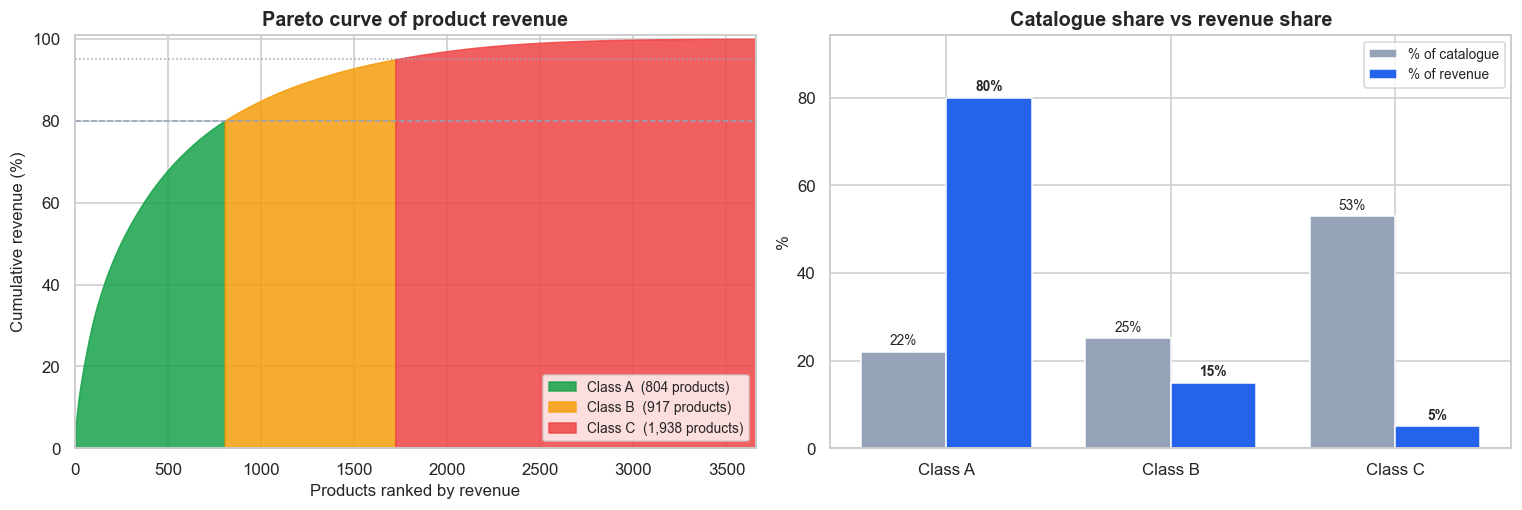

Class A: 804 products (22.0% of catalogue) -> 80.0% of revenue (GBP 8,415 each)
Class C: 1,938 products (53.0% of catalogue) -> 5.0% of revenue (GBP 218 each)


In [30]:
cls_colors = {"A": GREEN, "B": ACCENT2, "C": RED}

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

for cls in ["A", "B", "C"]:
    sub = abc[abc["Class"] == cls]
    ax[0].fill_between(sub["rank"], sub["cumulative_%"], color=cls_colors[cls], alpha=0.85,
                       label=f"Class {cls}  ({len(sub):,} products)")
ax[0].axhline(80, color=MUTED, ls="--", lw=1)
ax[0].axhline(95, color=MUTED, ls=":", lw=1)
ax[0].set(title="Pareto curve of product revenue", xlabel="Products ranked by revenue",
          ylabel="Cumulative revenue (%)", ylim=(0, 101), xlim=(0, len(abc)))
ax[0].legend(loc="lower right", fontsize=9)

share_bars(ax[1], abc_summary["% of products"], abc_summary["% of revenue"],
           "% of catalogue", "% of revenue")
ax[1].set(title="Catalogue share vs revenue share",
          xticklabels=[f"Class {c}" for c in abc_summary.index])

plt.tight_layout()
plt.savefig(f"{VIEWS}/abc_analysis.png")
plt.show()

a, c = abc_summary.loc["A"], abc_summary.loc["C"]
print(f"Class A: {a['products']:,.0f} products ({a['% of products']}% of catalogue) -> {a['% of revenue']}% of revenue "
      f"(GBP {a['revenue_per_product']:,.0f} each)")
print(f"Class C: {c['products']:,.0f} products ({c['% of products']}% of catalogue) -> {c['% of revenue']}% of revenue "
      f"(GBP {c['revenue_per_product']:,.0f} each)")

A textbook Pareto effect: **22% of the catalogue (804 products) generates 80% of revenue**, while **53%
(1,938 products) contributes only the last 5%** — an average of ~£218 each across the entire year. Class C
still consumes warehouse space, catalogue slots and purchase-order overhead, so it is the natural place to
look for range rationalisation. Class A is where stock-out prevention pays for itself.

### 7.3 Returns and cancellations

In [31]:
returns = (df_cancelled.groupby("StockCode")
             .agg(returned_units=("Quantity", "sum"), returned_value=("Revenue", "sum"))
             .abs())

# A return rate is only meaningful against how much of that product was actually sold
ret = product.join(returns, how="inner")
ret["return_rate_%"] = (ret["returned_units"] / ret["units"] * 100).round(1)

# Restrict to products with real volume so tiny denominators cannot dominate the ranking
MIN_UNITS = 500
worst = ret[ret["units"] >= MIN_UNITS].nlargest(10, "return_rate_%")

print(f"Products with a recorded return : {len(ret):,} of {len(product):,}")
print(f"Return rates above 100%         : {(ret['return_rate_%'] > 100).sum()} "
      "(returns of units bought before the window or via guest checkout)")
worst[["Description", "units", "returned_units", "return_rate_%", "revenue"]].round(2)

Products with a recorded return : 1,897 of 3,659
Return rates above 100%         : 8 (returns of units bought before the window or via guest checkout)


,Description,units,returned_units,return_rate_%,revenue
StockCode,,,,,
84347,ROTATING SILVER ANGELS T-LIGHT HLDR,7892,9367,118.7,17554.27
23113,PANTRY CHOPPING BOARD,1138,946,83.1,5695.86
47566B,TEA TIME PARTY BUNTING,2288,1424,62.2,10430.40
23055,IVORY CHANDELIER T-LIGHT HOLDER,560,336,60.0,1286.72
23056,FLOWERS CHANDELIER T-LIGHT HOLDER,866,483,55.8,2789.66
23057,BEADED CHANDELIER T-LIGHT HOLDER,674,337,50.0,1646.14
22105,MIRROR MOSAIC GOBLET CANDLE HOLDER,506,240,47.4,566.50
22102,MIRROR MOSAIC T-LIGHT HOLDER,1533,720,47.0,715.05
22313,OFFICE MUG WARMER PINK,553,250,45.2,1482.89


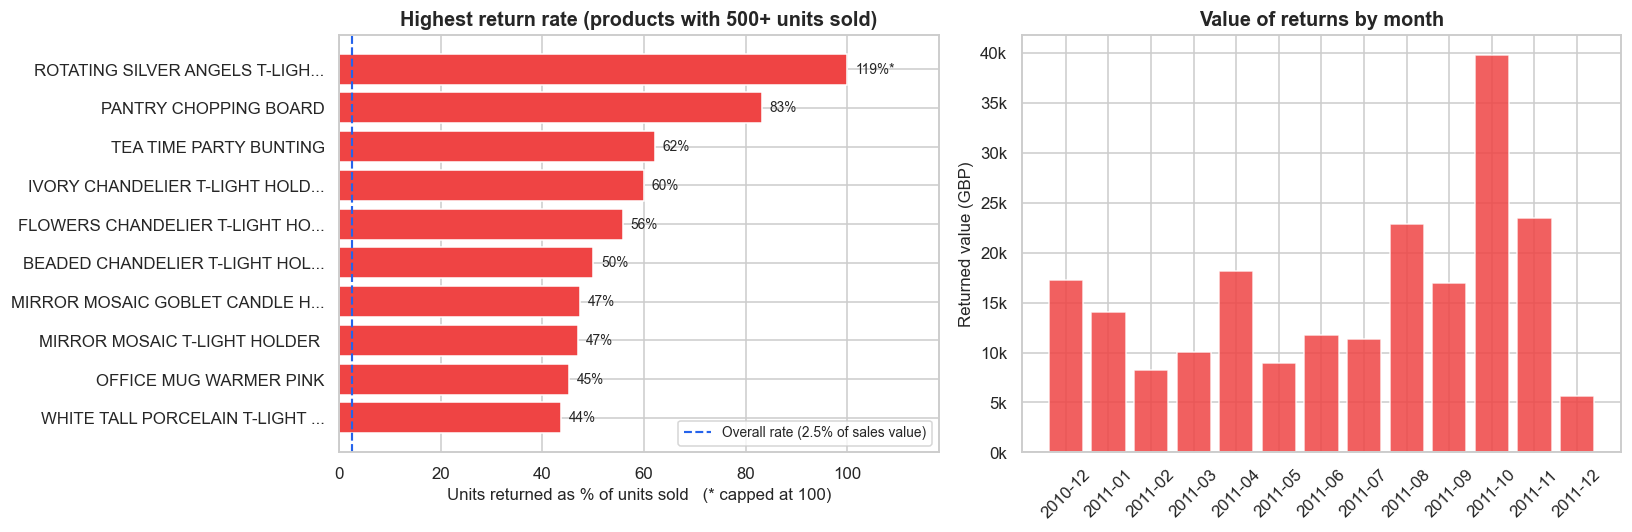

In [32]:
plot_worst = worst.iloc[::-1].copy()
plot_worst["capped"] = plot_worst["return_rate_%"].clip(upper=100)
monthly_ret = (df_cancelled.assign(YearMonth=df_cancelled["InvoiceDate"].dt.to_period("M").astype(str))
                 .groupby("YearMonth")["Revenue"].sum().abs())
overall = df_cancelled["Revenue"].abs().sum() / df["Revenue"].sum() * 100

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].barh([shorten(d, 30) for d in plot_worst["Description"]], plot_worst["capped"], color=RED)
for i, v in enumerate(plot_worst["return_rate_%"]):
    ax[0].text(min(v, 100) + 1.5, i, f"{v:.0f}%" + ("*" if v > 100 else ""), va="center", fontsize=9)
ax[0].axvline(overall, color=ACCENT, ls="--", lw=1.4, label=f"Overall rate ({overall:.1f}% of sales value)")
ax[0].set(title=f"Highest return rate (products with {MIN_UNITS}+ units sold)",
          xlabel="Units returned as % of units sold   (* capped at 100)", xlim=(0, 118))
ax[0].legend(fontsize=9, loc="lower right")

ax[1].bar(monthly_ret.index, monthly_ret.values, color=RED, alpha=0.85)
ax[1].set(title="Value of returns by month", xlabel="", ylabel="Returned value (GBP)")
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(gbp))
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{VIEWS}/returns_analysis.png")
plt.show()

Returns cost **~2.5% of gross sales**, but they are not spread evenly. A short list of products returns at
**40-100%+ of units sold** — heavily concentrated in **t-light and chandelier candle holders**, a fragile
glass/ceramic category. That pattern points at packaging and shipping damage rather than customer preference,
which is a fixable operational problem: each return pays shipping twice plus handling, so fixing packaging on
a handful of SKUs recovers more margin than a broad discount campaign.

<a id="findings"></a>
## 8. Key findings

### Data quality
- The raw export was only **72% usable**. The single largest loss was **135,080 rows (24.9%) with no
  `CustomerID`** — guest checkouts and stock write-offs (`damages`, `thrown away`, `Unsaleable`) that cannot
  support customer-level analysis. All 1,454 missing product descriptions sat inside that same block.
- **5,268 exact duplicate rows** would have inflated revenue, and **16 non-product `StockCode`s** (postage,
  bank charges, gift vouchers, manual adjustments) would have polluted every product ranking. A naive
  "non-numeric code" filter would also have wrongly deleted real merchandise, so codes were reviewed
  individually.
- **13 bulk sale lines were reversed by a matching cancellation minutes after being entered** — including a
  single **£168,470** line cancelled 12 minutes later. Left in, these data-entry errors would have ranked as
  the #1 and #2 products by revenue.
- Final analysis-ready dataset: **391,140 line items, 4,333 customers, 3,659 products, £8.46M revenue**,
  37 countries, £460 average order value.

### Demand patterns
- Strong **Q4 seasonality**: November (£1.14M) is **2.6x** the April trough. The rise is **2.3x order volume
  against only +11% average order value**, so fulfilment capacity — not pricing — is the constraint from
  September onward.
- Orders cluster into a **10:00-15:00 weekday window (79% of all orders)** with a midday peak, and there are
  **zero Saturday transactions all year**. Combined with the £460 average order value, the customer mix looks
  **wholesale/B2B-leaning**, not evening consumer retail.

### Concentration — the recurring theme
- **Geography:** the UK drives **82% of revenue**. Several export markets are tiny in customer count but carry
  a far higher average order value (Netherlands ~£3,050/order from 9 customers), which favours named-account
  management over broad marketing abroad.
- **Products:** **22% of the catalogue produces 80% of revenue**; 53% contributes the final 5%. Class C is the
  obvious candidate for range rationalisation.
- **Returns:** ~2.5% of gross sales, concentrated in fragile glass/ceramic candle holders — an operational
  packaging problem, not a demand problem.

Revenue is concentrated on every axis measured so far. **Part 2** tests whether the customer base follows the
same rule, and builds the segmentation to act on it.